# Probabilistic quality window by GPQR

In [ ]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.insert(0, os.path.abspath(".."))

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

In [ ]:
SLURRY_ORDER = ("G50", "G45", "G40", "G40+IPA")
LABELS = {
    "Gap_to_thickness_ratio": r"$R_\mathrm{gt}$",
    "Capillary_number": r"$\mathrm{Ca}$",
}

## Load data

In [ ]:
Xtrue = pd.read_csv("../_temp/X.csv")
Xpred = pd.read_csv("../_temp/X-pred.csv", index_col=[0, 1, 2])
joint = np.load("../_temp/joint_probability.X-pred.npz")
Delaunay = np.load("../_temp/X-delaunay.npy")

In [ ]:
slurry_levels = Xpred.index.get_level_values("Slurry")
groups = list(Xtrue.groupby("Slurry"))
slurries = [slurry for slurry, _ in groups]
slurry_idxs = [slurries.index(slurry) for slurry in SLURRY_ORDER]
groups = [groups[i] for i in slurry_idxs]
Delaunay = Delaunay[slurry_idxs, ...]

## Plot

In [ ]:
grids = [joint["grids"][i] for i in slurry_idxs]
probs = [joint["probs"][i] for i in slurry_idxs]

all_valid_x = np.concatenate([g[..., 0][Delaunay[i]] for i, g in enumerate(grids)])
all_valid_y = np.concatenate([g[..., 1][Delaunay[i]] for i, g in enumerate(grids)])

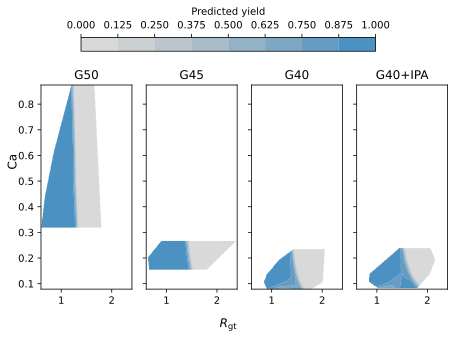

In [ ]:
N_COLORS = 8
cmap = mcolors.LinearSegmentedColormap.from_list(
    "gray_blue",
    [mcolors.to_rgba("gray", alpha=0.3), mcolors.to_rgba("tab:blue", alpha=0.8)],
    N=N_COLORS,
)

levels = np.linspace(0.0, 1.0, N_COLORS + 1)
norm = mcolors.BoundaryNorm(levels, ncolors=N_COLORS)

fig, axes = plt.subplots(1, len(SLURRY_ORDER), sharex=True, sharey=True)

for i, (slurry, sub_df) in enumerate(groups):
    ax = axes[i]
    xpred = grids[i]
    delaunay = Delaunay[i, ...].copy()

    prob_masked = np.full_like(delaunay, np.nan, dtype=float)
    prob_masked[delaunay] = probs[i][delaunay]

    ax.contourf(
        xpred[..., 0],
        xpred[..., 1],
        np.ma.masked_invalid(prob_masked),
        cmap=cmap,
        norm=norm,
        levels=levels,
    )
    ax.set_title(slurry)

fig.tight_layout(rect=[0.02, 0.05, 1.0, 0.8])

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.18, 0.82, 0.64, 0.04])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Predicted yield", labelpad=6)
cbar.ax.xaxis.set_ticks_position("top")
cbar.ax.xaxis.set_label_position("top")
cbar.ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

fig.supxlabel(LABELS[Xpred.columns[0]])
fig.supylabel(LABELS[Xpred.columns[1]])

fig.show()